# Training with an imzDesk dataset

This notebook loads an imzDesk dataset manifest, applies preprocessing and a random spatial crop, and returns tensors that can be consumed by a PyTorch `DataLoader`.

Install the notebook and model dependencies first with `pip install "imzdesk[examples,embeddings]"`.

## Notes

- `WORKSPACE` is the same directory opened by the imzDesk application.
- `DATASET_ID` is the manifest ID, not its editable display name. Manifests live in `WORKSPACE/.imzDesk/datasets`.
- Every manifest sample references files relative to the workspace.
- A paired sample has `wsi` and `msi` entries and must already have an imzDesk registration sidecar before a shared `RandomCrop` can be used. Registration matrices use the MSI pixel resolution.
- imzDesk currently assumes the files in one directory belong to one sample and does not resolve cross-directory references.
- Raw MSI spectra are ragged and cannot usually be stacked into a batch. This example bins and reduces them to a scalar image before tensor conversion.
- `Parallel` can infer full-frame resizing. A transform that crops, rotates, translates, or flips a modality must return a `SpatialImage` with an updated spatial frame.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

import imzdesk.transforms as T
from imzdesk.core import PairedImage
from imzdesk.data import Dataset, DatasetManifest

## Select the manifest

Change these values to point at an existing workspace and manifest. Loading is intentionally strict: a missing workspace, manifest, split, sample file, or required registration raises immediately instead of producing a partially usable training dataset.

In [2]:
WORKSPACE = Path('/mnt/Storage/Datasets/OmicsDB/MTBLS289')  # TODO
DATASET_ID = '636e448504'  # TODO: Grab it from the web app
SPLIT = 'train'

In [3]:
manifest = DatasetManifest.from_workspace(WORKSPACE, DATASET_ID)
print(f'{manifest.name}: {manifest.kind}')
print({name: len(samples) for name, samples in manifest.splits.items()})

MTBLS289: paired
{'train': 3, 'validation': 1, 'test': 1}


## Build the transform

Single-modality datasets use ordinary `Compose` pipelines. For paired datasets, `RandomCrop` first receives the complete raw pair, samples one valid physical region, and maps that region into both modalities using the stored registration. `Parallel` then applies modality-specific processing to the cropped data. This lets the WSI use an efficient region read and limits MSI normalization, binning, and reduction to the selected patch.

The crop is expressed as `(height, width)` pixels at `TARGET_MPP` microns per pixel. The WSI branch is rasterized at that resolution. The MSI branch performs TIC normalization, m/z binning, and total-ion-current projection before rasterization. Because this target grid is finer than the native MSI grid, `ToImage(interpolation='nearest')` fills each raster location from the nearest measured MSI pixel. Interpolation happens after projection; it does not duplicate the raw spectra.

In [4]:
TARGET_MPP = 20.0
CROP_SIZE = (160, 160)

msi_operations = [
    T.Normalize('tic'),
    T.Bin(minimum_channel=600, maximum_channel=1000, bin_width=1),
    T.TIC(),  # Should probably be excluded from any modeling pipeline, but we add it here for visualization purposes
    T.ToImage(interpolation='nearest'),
]

if manifest.kind == 'paired':
    transform = T.Compose([
        T.RandomCrop(CROP_SIZE, mpp=TARGET_MPP),
        T.Parallel(msi=T.Compose(msi_operations)),
        T.ToTensor(dtype=torch.float32),
    ])
elif manifest.kind == 'wsi':
    transform = T.Compose([
        T.RandomCrop(CROP_SIZE, mpp=TARGET_MPP, seed=0),
        T.ToTensor(dtype=torch.float32),
    ])
else:
    transform = T.Compose([
        T.ToRImage(),
        *msi_operations,
        T.RandomCrop(CROP_SIZE, seed=0),
        T.ToTensor(dtype=torch.float32),
    ])

## Create the dataset and DataLoader

`Dataset` implements the map-style `__len__` and `__getitem__` protocol expected by PyTorch; it does not inherit from a Torch class. Image objects are constructed in `__getitem__`, so DataLoader workers do not inherit open slide handles from the parent process.

After `ToTensor`, dense images use channel-first `(C, H, W)` layout. Registered pairs remain a `PairedImage`, and the registration between the current WSI and MSI grids is converted to a tensor as its third field. After the shared crop this matrix is identity. Because the random crop gives every sample the same spatial shape, PyTorch's default collator can stack them.

In [5]:
dataset = Dataset(
    workspace=WORKSPACE,
    dataset_id=DATASET_ID,
    split=SPLIT,
    transform=transform,
)

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,  # Increase after validating the pipeline locally.
)

print(f'{len(dataset)} samples in {SPLIT!r}')

3 samples in 'train'


## Inspect one random sample

This reads and transforms only one item. For a paired dataset, both panels show the same registered physical crop. MSI is scalar in this example, while WSI is RGB.

Loading 0


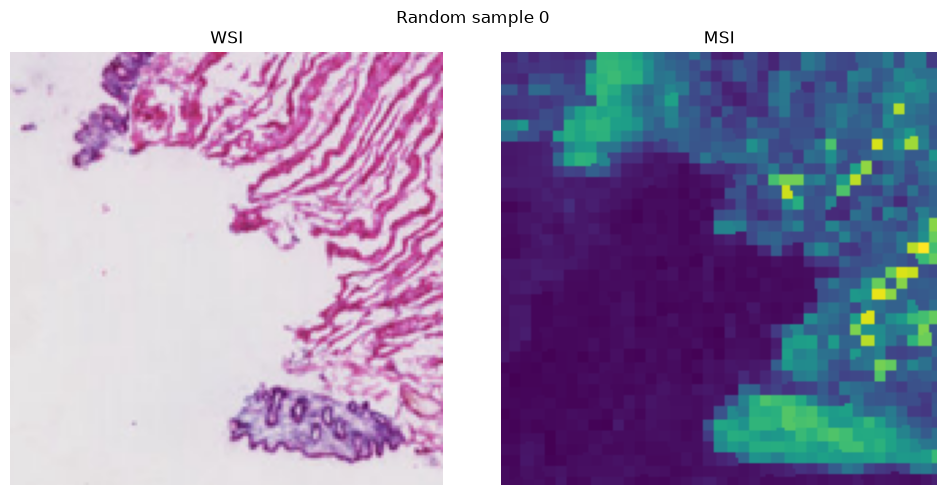

In [8]:
index = int(torch.randint(len(dataset), size=()).item())
print('Loading', index)

sample = dataset[index]

def display_array(tensor):
    array = tensor.detach().cpu().numpy()
    if array.ndim == 3 and array.shape[0] == 1:
        return array[0]
    if array.ndim == 3:
        return array[:3].transpose(1, 2, 0)
    return array

if isinstance(sample, PairedImage):
    figure, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(display_array(sample.wsi).clip(0, 255).astype('uint8'))
    axes[0].set_title('WSI')
    axes[1].imshow(display_array(sample.msi), cmap='viridis')
    axes[1].set_title('MSI')
    for axis in axes:
        axis.axis('off')
else:
    plt.figure(figsize=(5, 5))
    plt.imshow(display_array(sample), cmap='viridis' if sample.shape[0] == 1 else None)
    plt.axis('off')

plt.suptitle(f'Random sample {index}')
plt.tight_layout()